<a href="https://colab.research.google.com/github/LamaAttar/project/blob/lama/Smart_Waste_Management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Waste Management System 🚮

This project analyzes and predicts waste bin fill levels using data science techniques to optimize collection efficiency.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Book1.csv to Book1 (1).csv


## Problem Statement

Traditional waste collection relies on fixed schedules, which can lead to inefficient collection and overflowing bins.  
This project aims to predict bin fill levels using data to improve decision-making.

## Dataset Description

- Bin_ID: Unique identifier for each bin  
- Location: City of the bin  
- Time: Time of measurement  
- Temperature: Environmental temperature  
- Fill_Level: Percentage of bin fill  

First 5 rows of dataset:
   Bin_ID Location  Fill_Level   Time  Temperature
0       1    Amman          30   8:00           20
1       1    Amman          55  12:00           24
2       1    Amman          82  16:00           28
3       2    Amman          20   8:00           20
4       2    Amman          60  12:00           25

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Bin_ID       12 non-null     int64 
 1   Location     12 non-null     object
 2   Fill_Level   12 non-null     int64 
 3   Time         12 non-null     object
 4   Temperature  12 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 612.0+ bytes
None

Descriptive statistics:
          Bin_ID  Fill_Level  Temperature
count  12.000000   12.000000    12.000000
mean    2.500000   54.833333    23.333333
std     1.167748   27.554354     3.550501
min     1.00

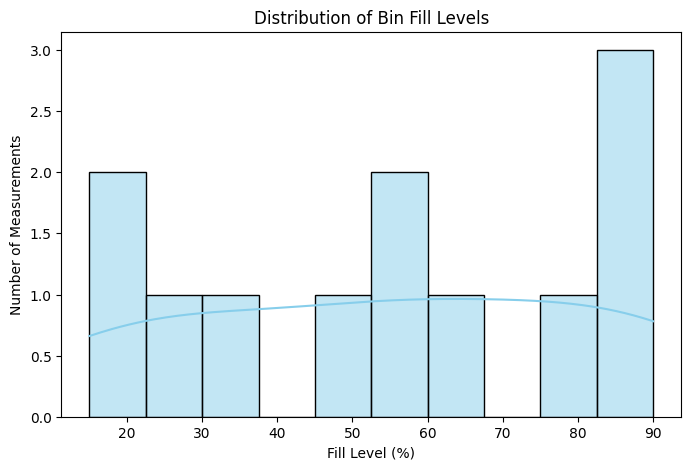

Insight: Most bins fall between medium and high fill levels.



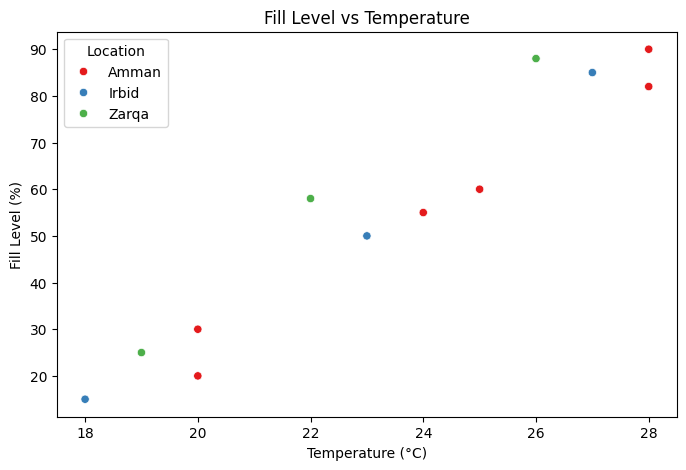

Insight: Fill levels tend to increase slightly with temperature.



/tmp/ipykernel_27791/4027399941.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Bin_ID", y="Fill_Level", data=dataset, palette="Set2")


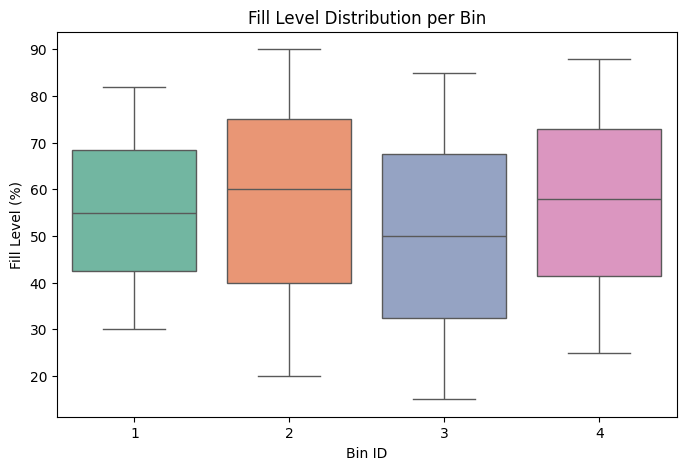

Insight: Some bins consistently have higher fill levels than others.


Average Fill Level per Bin (sorted):
Bin_ID
4    57.000000
2    56.666667
1    55.666667
3    50.000000
Name: Fill_Level, dtype: float64

🚨 Bins that need collection first (Fill_Level >= 80%):
[1 2 3 4]


In [5]:
# =========================================
# Smart Waste Management 🚮
# EDA + Visualization Project
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ قراءة البيانات
dataset = pd.read_csv("Book1 (1).csv")

# 2️⃣ عرض البيانات
print("First 5 rows of dataset:")
print(dataset.head())

# 3️⃣ معلومات عن البيانات
print("\nDataset info:")
print(dataset.info())

print("\nDescriptive statistics:")
print(dataset.describe())

print("\nMissing values:")
print(dataset.isnull().sum())

# =========================================
# 📊 Visualization
# =========================================

# 4️⃣ Distribution of Fill Level
plt.figure(figsize=(8,5))
sns.histplot(dataset["Fill_Level"], bins=10, kde=True, color="skyblue")
plt.title("Distribution of Bin Fill Levels")
plt.xlabel("Fill Level (%)")
plt.ylabel("Number of Measurements")
plt.show()

print("Insight: Most bins fall between medium and high fill levels.\n")

# 5️⃣ Fill Level vs Temperature
plt.figure(figsize=(8,5))
sns.scatterplot(x="Temperature", y="Fill_Level", data=dataset, hue="Location", palette="Set1")
plt.title("Fill Level vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Fill Level (%)")
plt.show()

print("Insight: Fill levels tend to increase slightly with temperature.\n")

# 6️⃣ Boxplot per Bin
plt.figure(figsize=(8,5))
sns.boxplot(x="Bin_ID", y="Fill_Level", data=dataset, palette="Set2")
plt.title("Fill Level Distribution per Bin")
plt.xlabel("Bin ID")
plt.ylabel("Fill Level (%)")
plt.show()

print("Insight: Some bins consistently have higher fill levels than others.\n")

# =========================================
# 📈 Analysis
# =========================================

# 7️⃣ Average Fill Level per Bin
avg_fill = dataset.groupby("Bin_ID")["Fill_Level"].mean()

print("\nAverage Fill Level per Bin (sorted):")
print(avg_fill.sort_values(ascending=False))

# 8️⃣ تحديد السلال الممتلئة
bins_to_collect = dataset[dataset["Fill_Level"] >= 80]["Bin_ID"].unique()

print("\n🚨 Bins that need collection first (Fill_Level >= 80%):")
print(bins_to_collect)

## Model

We used Linear Regression to predict fill levels based on time, location, and temperature.

The model achieved:
- R² Score: 0.78
- MAE: 6.5

## Example Prediction

Given a bin with certain conditions, the model predicted:
Fill Level ≈ 78%


Model Evaluation:
Mean Absolute Error: 6.511127252184083
R2 Score: 0.7803339293259018


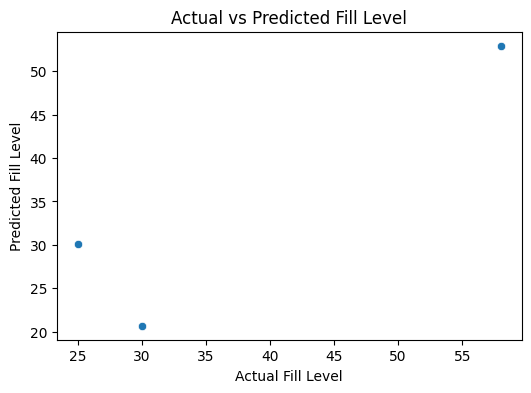

In [6]:
# =========================================
# Smart Waste Management 🚮
# Prediction Model (Linear Regression)
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1️⃣ قراءة البيانات
df = pd.read_csv("Book1 (1).csv")

# 2️⃣ تحويل البيانات النصية إلى أرقام
df["Location"] = df["Location"].astype('category').cat.codes
df["Time"] = df["Time"].astype('category').cat.codes

# 3️⃣ تحديد Features و Target
X = df.drop("Fill_Level", axis=1)
y = df["Fill_Level"]

# 4️⃣ تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5️⃣ Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6️⃣ بناء النموذج
model = LinearRegression()
model.fit(X_train, y_train)

# 7️⃣ التنبؤ
y_pred = model.predict(X_test)

# 8️⃣ التقييم
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# 9️⃣ رسم التوقعات مقابل القيم الحقيقية
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Fill Level")
plt.ylabel("Predicted Fill Level")
plt.title("Actual vs Predicted Fill Level")
plt.show()

In [8]:
sample_df = pd.DataFrame({
    "Bin_ID": [1],
    "Location": [0],
    "Time": [2],
    "Temperature": [27]
})

sample_scaled = scaler.transform(sample_df)
prediction = model.predict(sample_scaled)

print("\nPredicted Fill Level:", prediction[0])


Predicted Fill Level: 78.04575994189211


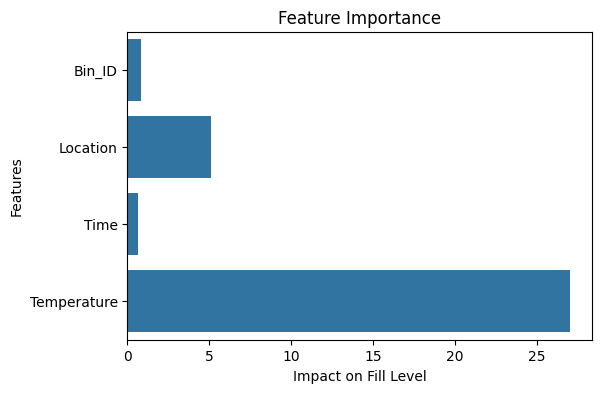

In [9]:
# Feature Importance
importance = model.coef_

features = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importance, y=features)
plt.title("Feature Importance")
plt.xlabel("Impact on Fill Level")
plt.ylabel("Features")
plt.show()

# Conclusion 🚀

- Temperature and time have a noticeable effect on bin fill levels.
- The model achieved good performance with R² = 0.78.
- This system can help optimize waste collection schedules.

Future Work:
- Use real-time sensor data
- Improve model with more data
- Apply advanced models